In [3]:
%matplotlib widget
import sys, importlib, os
import McsPy.McsData
import McsPy.McsCMOS
from McsPy import ureg, Q_

# matplotlib.pyplot will be used in these examples to generate the plots visualizing the data
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.widgets import Slider
import numpy as np
from scipy import signal

# import datashader as ds
# import datashader.transfer_functions as tf
import pandas as pd

na = np.array
import scipy.signal
import matplotlib.pyplot as plt

import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import h5py
import os 
def compute_latency_map(V, window, mode='trough'):
    """
    V: shape (n_channels, n_timepoints)
    window: tuple (t_start, t_end) — indices to restrict search
    mode: 'trough' or 'peak'
    Returns: latency_map of shape (n_channels,)
    """
    t_start, t_end = window
    V_window = V[:, t_start:t_end]
    # V_window[np.where(V_window<20)] = 0 
    print(V_window.shape)
    if mode == 'trough':
        idx = np.argmin(V_window, axis=1)
    elif mode == 'peak':
        idx = np.argmax(V_window, axis=1)
    else:
        raise ValueError("mode must be 'trough' or 'peak'")

    # latencies = t_start + idx  # shift to global time index
    return idx#latencies

In [11]:
rec_table = pd.read_csv('/mnt/server_epl/SCN1A/R1648H-analysis/recordings-main.csv')

In [21]:
rec_table

,date,mouse age,mouseID,slice,Valid,genotype,Sex,recording,protocol,duration,...,recording solution,Perfusion speed,visible areas,dissection,slice type,file_name,path,image_path,harp,comments about slice
0,28.10.24,P14,1,slice1,WAHR,wt,?,1.0,5-10-10,5.0,...,0Mg,"1,5",NaN,Stefano,coronal,2024-10-28T11-20-06slice1,28-10-24/slice1,NaN,OPEN,slice name in the filename is arbitrary (see d...
1,28.10.24,P14,1,slice1,WAHR,wt,?,2.0,5-10-10,10.0,...,0Mg,"1,5",NaN,Stefano,coronal,2024-10-28T11-30-32slice1,28-10-24/slice1,NaN,OPEN,NaN
2,28.10.24,P14,1,slice1,WAHR,wt,?,3.0,5-10-10,10.0,...,0Mg,"1,5",NaN,Stefano,coronal,2024-10-28T11-58-02slice1,28-10-24/slice1,NaN,OPEN,NaN
3,28.10.24,P14,1,slice2,WAHR,wt,?,1.0,5-10-10,5.0,...,0Mg,"1,5",NaN,Stefano,coronal,2024-10-28T12-21-14slice2,28-10-24/slice2,NaN,OPEN,NaN
4,28.10.24,P14,1,slice2,WAHR,wt,?,2.0,5-10-10,10.0,...,0Mg,"1,5",NaN,Stefano,coronal,2024-10-28T12-35-01slice2,28-10-24/slice2,NaN,OPEN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,26.3.25,P20,15,slice5,NaN,?,male,NaN,10-40,20.0,...,0Mg,3,hpc,Oleg,horizontal,2025-03-26T15-29-35McsRecording,26-3-25\slice5,26-3-25\slice5\stack,OPEN,NaN
177,26.3.25,P20,15,slice6,NaN,?,male,1.0,5-10-10,5.0,...,0Mg,3,hpc,Oleg,horizontal,2025-03-26T15-45-41McsRecording,26-3-25\slice6,26-3-25\slice6\stack,OPEN,NaN
178,26.3.25,P20,15,slice6,NaN,?,male,2.0,10-40,NaN,...,0Mg,3,hpc,Oleg,horizontal,2025-03-26T15-54-35McsRecording,26-3-25\slice6,26-3-25\slice6\stack,OPEN,NaN
179,26.3.25,P20,15,slice7,NaN,?,male,NaN,5-10-10,5.0,...,0Mg,3,hpc,Oleg,horizontal,2025-03-26T16-19-27McsRecording,26-3-25\slice7,26-3-25\slice7\stack,OPEN,NaN


In [94]:
i_num = 100
rec_table.iloc[i_num]

date                                                              3.12.24
mouse age                                                             P20
mouseID                                                                 9
slice                                                              slice4
Valid                                                                 NaN
genotype                                                               wt
Sex                                                                female
recording                                                             2.0
protocol                                                          5-10-10
duration                                                             10.0
comments                slice has both hemispheres! Harp is removed; n...
temperature                                                          36.0
recovery solution                                                 sucrose
Sampling Rate                         

In [97]:
#set img path 
img_path = '/mnt/server_epl/SCN1A/R1648/'+rec_table.iloc[i_num].image_path + '/Fused.tif'
img_path =img_path.replace('\\','/')


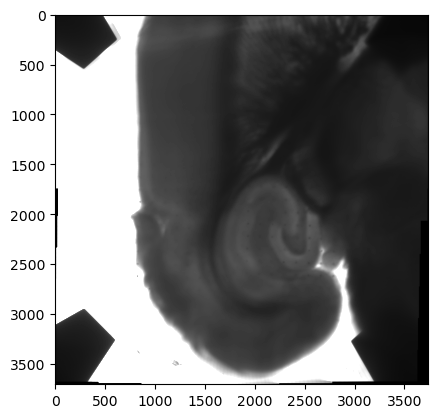

In [98]:
I = plt.imread(img_path)
plt.imshow(I,cmap='gray',vmax=5000)

In [128]:
from datetime import datetime

path = rec_table.iloc[i_num].path.replace('\\','/')
file_name = rec_table.iloc[i_num].file_name
os.path.join(path,file_name)
slice_ =path.split('/')[-1]
date =path.split('/')[0]
dt = datetime.strptime(date, '%d-%m-%y')
date = dt.strftime('%d-%m-%y')
print(date)

filt_file_name = 'R1648H_'+date+'_'+slice_+'_'+file_name+'.h5_filtered.h5'



03-12-24


In [129]:
filt_path = '/mnt/server_epl/SCN1A/R1648H_filt'
target_file = os.path.join(filt_path,filt_file_name).replace('\\','/')

In [130]:
target_file

'/mnt/server_epl/SCN1A/R1648H_filt/R1648H_03-12-24_slice4_2024-12-03T14-15-41McsRecording.h5_filtered.h5'

In [131]:
print(filt_file_name)
print('R1648H_03-12-24_slice4_2024-12-03T13-55-42McsRecording.h5_filtered.h5')
# print('R1648H_28-10-24_slice1_2024-10-28T11-20-06slice1.h5_filtered.h5')

R1648H_03-12-24_slice4_2024-12-03T14-15-41McsRecording.h5_filtered.h5
R1648H_03-12-24_slice4_2024-12-03T13-55-42McsRecording.h5_filtered.h5


In [132]:

# file_name = '/Users/ovinogradov/Documents/Projects/SCN1A/MEA-analysis/data/Shaima_example/2025-01-17T21-17-46McsRecording.h5'

# ['/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-15-02McsRecording.h5_filtered.h5',

# '/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-29-29McsRecording.h5_filtered.h5'
 
#  '/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-52-02McsRecording.h5_filtered.h5'
# ]

# target_file ='/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_21-03-25_slice6_2025-03-21T14-42-46McsRecording.h5_filtered.h5'
# target_file = '/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_21-03-25_slice6_2025-03-21T14-52-28McsRecording.h5_filtered.h5'#/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-15-02McsRecording.h5_filtered.h5'
#'/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-29-29McsRecording.h5_filtered.h5'#'/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_21-03-25_slice6_2025-03-21T14-52-28McsRecording.h5_filtered.h5'
# with h5py.File('filtered.h5', 'r') as f:
with h5py.File(target_file, 'r') as f:
    # print(f.keys())
    print(f['data'].shape)
    filt = f['data'][:,:]
    subsampling_rate = f['resampled_rate']
# with h5py.File(file_name, "r") as f:
#     data= f['Data']['Recording_0']['AnalogStream']['Stream_0']['ChannelData']
#     print(data)
#     # chunk_size = 1000  # Choose an optimal chunk size
#     data_series = data[10,:]  # Process in chunks


(1027336, 252)


In [133]:
with h5py.File(target_file, 'r') as f:
    # print(f['data'].shape)
    # filt = f['data'][:,:]
    subsampling_rate = na(f['resampled_rate'])
    adc_step = na(f['scale'])

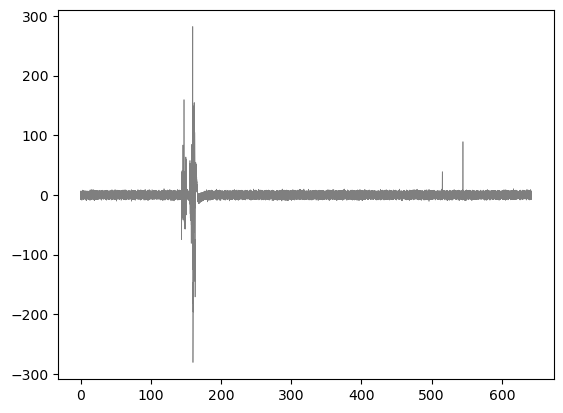

In [134]:
i=0
y= (filt[:,i]*adc_step)*mv_scale_factor
plt.plot(np.arange(0,len(filt[:]))*(1/(subsampling_rate)),y-i*40,'-',linewidth = 0.5,color='k',alpha=0.5)

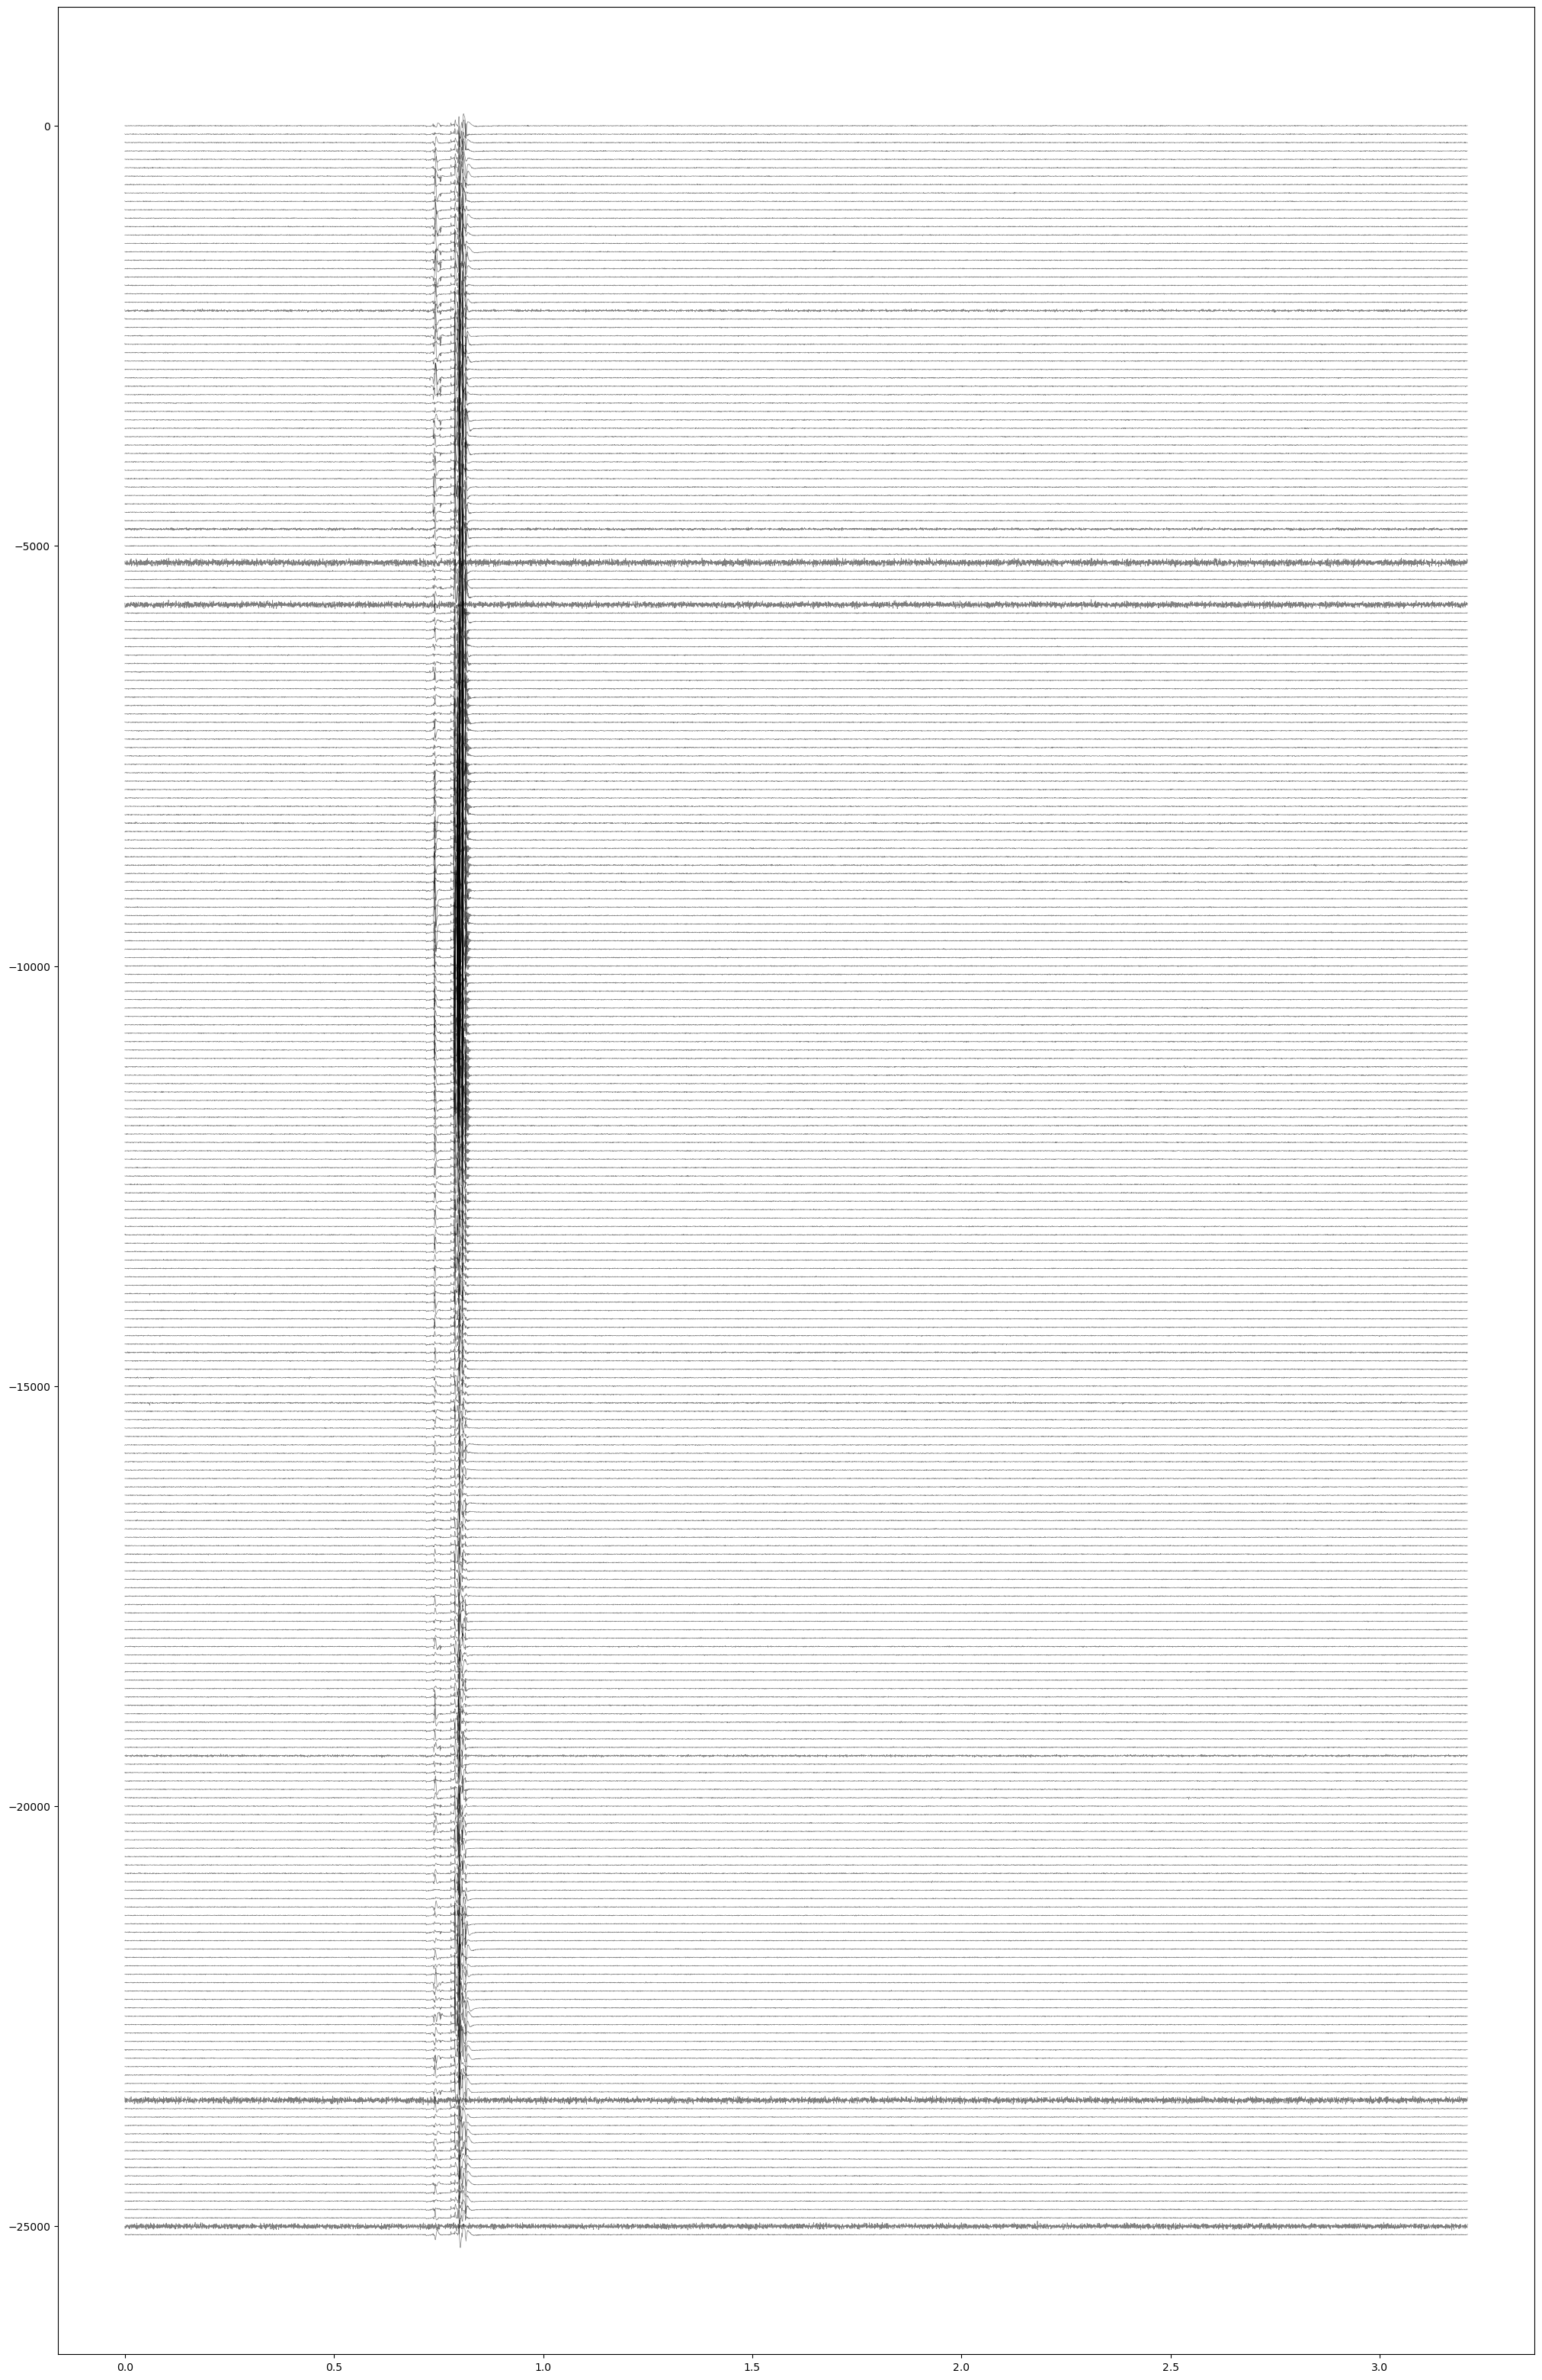

In [135]:
# import matplotlib.patches as patches
plt.figure(figsize = (25,40))


#68,70,72,74,76,78
mv_scale_factor =  1000000
for i in range(252):
    y= (filt[::200,i]*adc_step)*mv_scale_factor
    plt.plot(np.arange(0,len(filt[::200]))*(1/(subsampling_rate)),y-i*100,'-',linewidth = 0.5,color='k',alpha=0.5)
# plt.xlim(0,100.3)
# plt.plot([0,60*5],[-10,-10],color='k')
# plt.plot([0,0],[0,20],color='k')
# plt.text(2.,-.000062,'1min')
# blocks = [[2380,2410]]#[222,223],[1157,1158],
# for block in na(blocks): 
#     plt.axvspan(block[0],block[1],color='k',alpha=0.2)
# rect1 = patches.Rectangle((2, 2), 4, 3, linewidth=2, edgecolor='red', facecolor='none')

# plt.plot([-1,-1],[-.00002,.0000],color='k')
# plt.text(-4.,-.0000,'1µV')
# plt.ylim([-5e-5,8e-5])
# plt.axis('off')
# plt.show()

# plt.ax